# Simple Moving Average Crossover Strategy on EUR/USD

This notebook is for educational purposes only. It shows how a simple trend-following trading rule can be implemented with `pandas` on EUR/USD daily price data.


## 1. Imports

We begin with the core libraries used throughout the notebook: `pandas` for tabular time series work, `numpy` for numerical operations, and `matplotlib` for simple visualizations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Keep tables and charts easy to read in the notebook.
pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')


## 2. Load the EUR/USD Price Data

The notebook looks for a file called `eurusd.csv` in the current working directory. It expects a date column and a price column named `price`.

To keep the notebook runnable, a synthetic EUR/USD series is created only if the CSV is not available.


In [3]:
def find_date_column(columns):
    """Return the first column that looks like a date column."""
    for candidate in ['Date', 'date', 'DATE']:
        if candidate in columns:
            return candidate
    raise ValueError("No date column found. Expected one of: Date, date, DATE.")


csv_path = Path("eurusd.csv")

if csv_path.exists():
    raw_data = pd.read_csv(csv_path)
    date_column = find_date_column(raw_data.columns)

    if "price" not in raw_data.columns:
        raise ValueError("The CSV must contain a price column named price.")

    df = raw_data[[date_column, "price"]].copy()
    df[date_column] = pd.to_datetime(df[date_column], errors="coerce")
    df = df.dropna(subset=[date_column, "price"]).set_index(date_column).sort_index()
    data_source = "Loaded from eurusd.csv"
else:
    # Synthetic fallback so the notebook still runs if the CSV is missing.
    rng = np.random.default_rng(42)
    trading_days = pd.date_range("2010-01-01", "2018-12-31", freq="B")
    daily_log_moves = rng.normal(loc=0.0, scale=0.0045, size=len(trading_days))
    synthetic_price = 1.30 * np.exp(np.cumsum(daily_log_moves))
    df = pd.DataFrame({"price": synthetic_price}, index=trading_days)
    df.index.name = "Date"
    data_source = "Synthetic EUR/USD fallback (eurusd.csv not found)"

print(data_source)
print()
print("First five rows:")
print(df.head())
print()
print("Basic info:")
df.info()
print()
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Number of rows: {len(df):,}")


Synthetic EUR/USD fallback (eurusd.csv not found)

First five rows:
              price
Date               
2010-01-01 1.301784
2010-01-04 1.295706
2010-01-05 1.300089
2010-01-06 1.305603
2010-01-07 1.294191

Basic info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2347 entries, 2010-01-01 to 2018-12-31
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   price   2347 non-null   float64
dtypes: float64(1)
memory usage: 36.7 KB

Date range: 2010-01-01 to 2018-12-31
Number of rows: 2,347


## 3. Rolling Windows and Moving Averages

A rolling window means we repeatedly calculate a statistic over the most recent *N* observations. Here we use it to compute moving averages.

The first rows contain missing values because there are not yet enough past observations to calculate a full 50-day or 200-day average. For example, a 200-day moving average needs 200 daily prices before the first valid value appears.


In [4]:
# Calculate the short-term and long-term simple moving averages.
df["SMA_S"] = df["price"].rolling(window=50).mean()
df["SMA_L"] = df["price"].rolling(window=200).mean()

df[["price", "SMA_S", "SMA_L"]].head(10)


,price,SMA_S,SMA_L
Date,,,
2010-01-01,1.301784,NaN,NaN
2010-01-04,1.295706,NaN,NaN
2010-01-05,1.300089,NaN,NaN
2010-01-06,1.305603,NaN,NaN
2010-01-07,1.294191,NaN,NaN
2010-01-08,1.286629,NaN,NaN
2010-01-11,1.287369,NaN,NaN
2010-01-12,1.285539,NaN,NaN
2010-01-13,1.285442,NaN,NaN


## 4. Plot the Price Series with Both Moving Averages

This chart gives us a first visual impression of trend direction and how the short and long moving averages interact with the EUR/USD price series.


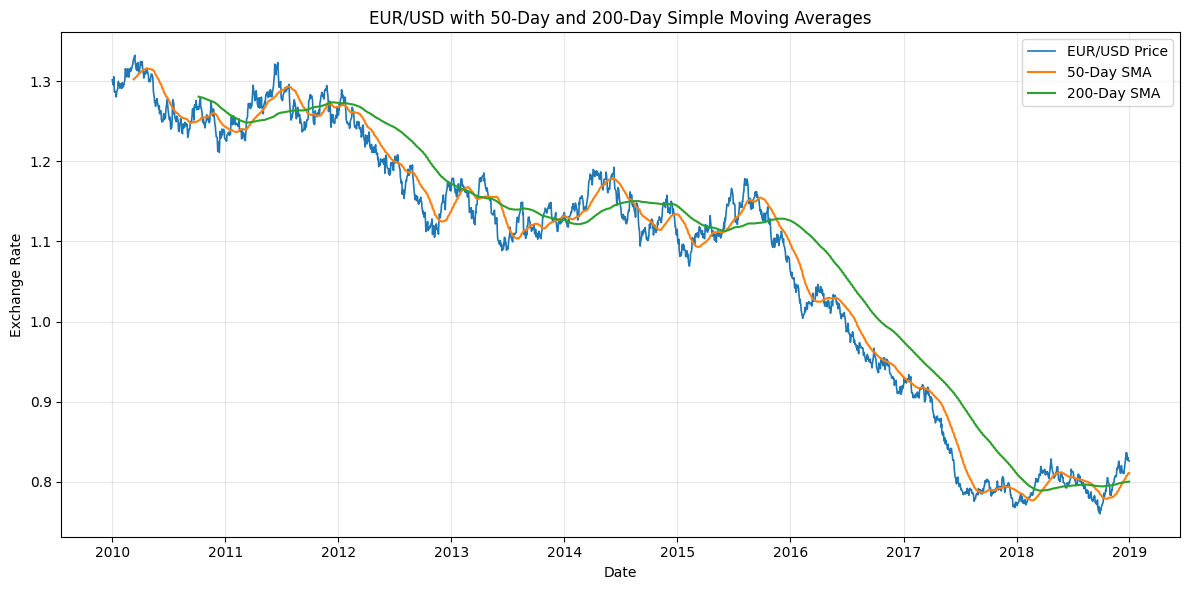

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["price"], label="EUR/USD Price", linewidth=1.2)
plt.plot(df.index, df["SMA_S"], label="50-Day SMA", linewidth=1.5)
plt.plot(df.index, df["SMA_L"], label="200-Day SMA", linewidth=1.5)
plt.title("EUR/USD with 50-Day and 200-Day Simple Moving Averages")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Remove Rows with Incomplete Moving Averages

Before we create trading signals, we remove rows where either moving average is missing. This is necessary because a crossover rule only makes sense once both averages are fully defined.


In [7]:
# Keep only rows where both moving averages are available.
strategy_data = df.dropna(subset=["SMA_S", "SMA_L"]).copy()

# Trading rule: long when the short SMA is above the long SMA, short otherwise.
strategy_data["position"] = np.where(strategy_data["SMA_S"] > strategy_data["SMA_L"], 1, -1)

strategy_data[["price", "SMA_S", "SMA_L", "position"]].head(10)


,price,SMA_S,SMA_L,position
Date,,,,
2010-10-07,1.264856,1.250800,1.280713,-1
2010-10-08,1.266779,1.251026,1.280538,-1
2010-10-11,1.274828,1.251530,1.280434,-1
2010-10-12,1.275348,1.252233,1.280310,-1
2010-10-13,1.279049,1.253063,1.280178,-1
2010-10-14,1.267303,1.253664,1.280043,-1
2010-10-15,1.267025,1.254063,1.279945,-1
2010-10-18,1.262226,1.254350,1.279819,-1
2010-10-19,1.255323,1.254389,1.279668,-1


## 6. Focus on 2016 Only

Looking at a shorter slice makes it easier to spot the moments where the short and long moving averages cross and the trading rule changes direction.


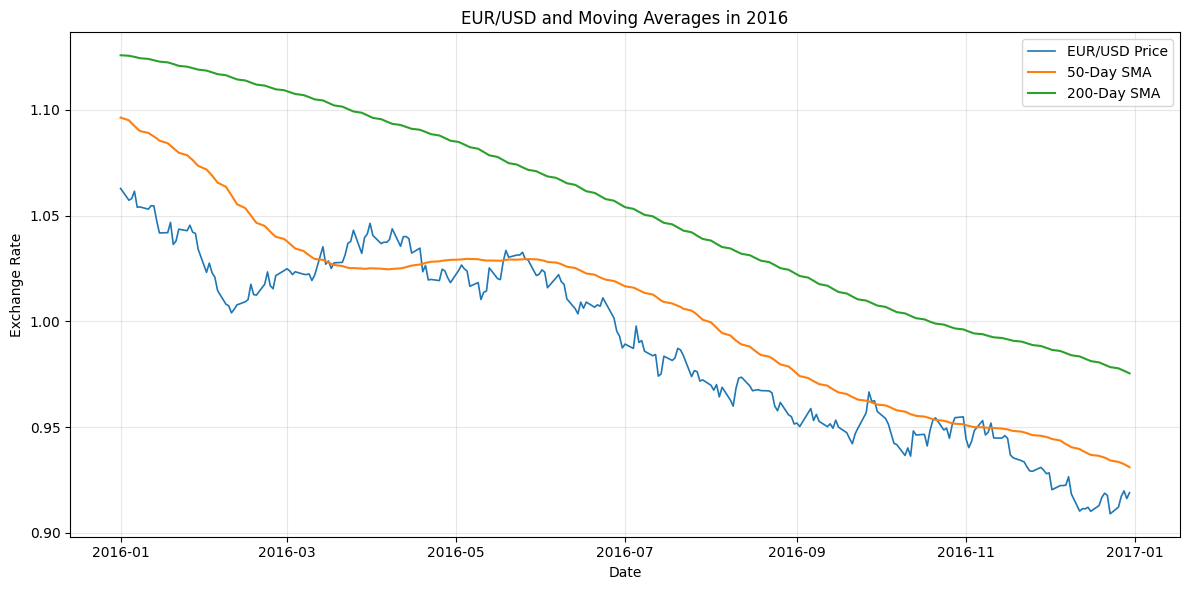

In [8]:
strategy_2016 = strategy_data.loc["2016"].copy()

plt.figure(figsize=(12, 6))
plt.plot(strategy_2016.index, strategy_2016["price"], label="EUR/USD Price", linewidth=1.2)
plt.plot(strategy_2016.index, strategy_2016["SMA_S"], label="50-Day SMA", linewidth=1.5)
plt.plot(strategy_2016.index, strategy_2016["SMA_L"], label="200-Day SMA", linewidth=1.5)
plt.title("EUR/USD and Moving Averages in 2016")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Visualize the Trading Signal in 2016

In the next chart, the moving averages stay on the main axis and the trading position is shown on a secondary axis. This makes the switch between long (`1`) and short (`-1`) much easier to see.


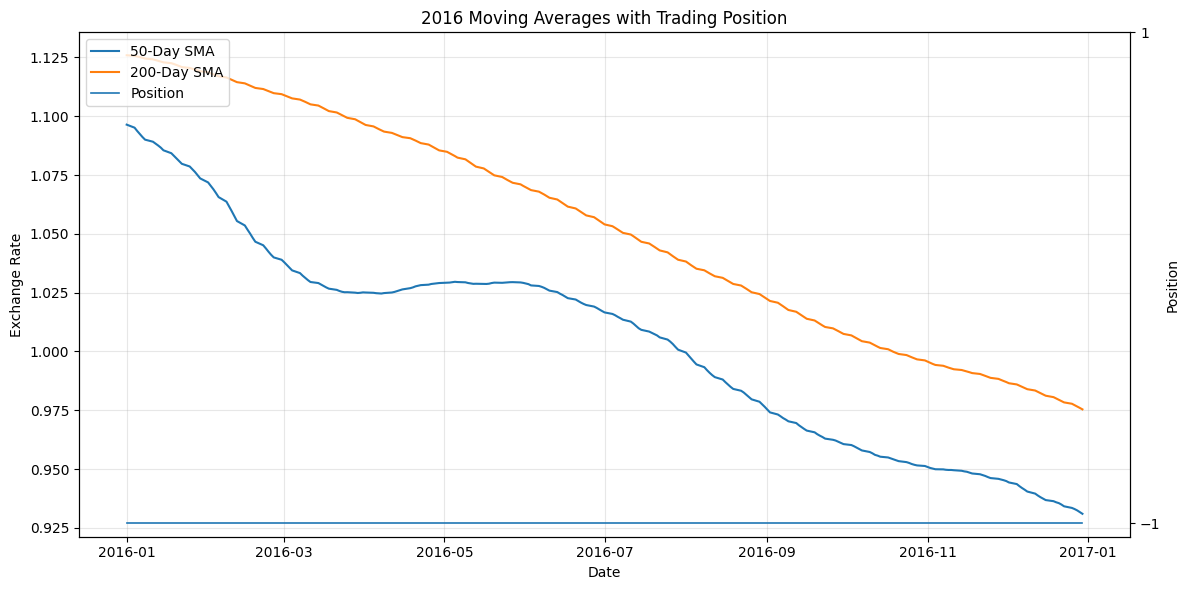

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(strategy_2016.index, strategy_2016["SMA_S"], label="50-Day SMA", linewidth=1.5)
ax1.plot(strategy_2016.index, strategy_2016["SMA_L"], label="200-Day SMA", linewidth=1.5)
ax1.set_title("2016 Moving Averages with Trading Position")
ax1.set_xlabel("Date")
ax1.set_ylabel("Exchange Rate")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.step(strategy_2016.index, strategy_2016["position"], where="post", label="Position", linewidth=1.2)
ax2.set_ylabel("Position")
ax2.set_yticks([-1, 1])

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()


## 8. Trading Intuition

- When the short SMA crosses **above** the long SMA, the strategy goes **long** because recent prices are stronger than the longer-term trend.
- When the short SMA crosses **below** the long SMA, the strategy goes **short** because recent prices are weaker than the longer-term trend.

This is a simple trend-following idea: we are not trying to predict every small move, only to react when short-term momentum appears to shift relative to the longer trend.


## 9. Final Summary

This notebook only builds the core strategy logic and signal generation for a moving average crossover rule. That is a useful first step, but it is not a full strategy evaluation.

A proper backtest should be done separately and would normally include returns, transaction costs, position changes, risk metrics, and performance analysis over time.
